# 01. EDA Findings and Modeling Decisions

Notebook này trình bày các phát hiện quan trọng từ EDA và chỉ ra các phát hiện đó dẫn đến những quyết định nào trong pipeline model cuối.

Nói cách khác, EDA không chỉ mô tả dữ liệu mà còn trả lời các câu hỏi phục vụ trực tiếp cho mô hình:

- Vì sao target dự báo là `max(Quantity, 0)` thay vì dùng `Quantity` thô?
- Vì sao cần tính `profit weight` theo WRMSSE trước khi chọn SKU để train?
- Top SKU chiếm bao nhiêu phần trăm profit và vì sao chọn nhóm top-weight SKU?
- Vì sao bài toán có tính long-tail/sparse demand?
- Vì sao final model dùng lag/rolling/date features, LightGBM ratio target và SKU-level correction factor?

Các kết luận trong notebook này là cơ sở cho pipeline final ở `02_data_preprocessing.ipynb`, `03_model_training_submission.ipynb` và `src/pipeline.py`.


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("TRAIN_PATH:", TRAIN_PATH)
print("SAMPLE_PATH:", SAMPLE_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

PROJECT_ROOT: /Users/apple/HBAAC/hbaac_demand_forecasting_repo
TRAIN_PATH: /Users/apple/HBAAC/hbaac_demand_forecasting_repo/data/raw/train.csv
SAMPLE_PATH: /Users/apple/HBAAC/hbaac_demand_forecasting_repo/data/raw/sample_submission.csv
OUTPUT_DIR: /Users/apple/HBAAC/hbaac_demand_forecasting_repo/outputs/eda


## 2. Load data và chuẩn hóa kiểu dữ liệu

Một điểm quan trọng của bộ dữ liệu là các cột tiền có thể dùng dấu phẩy thập phân, ví dụ `931189,87`. Vì vậy không dùng `pd.to_numeric` trực tiếp cho các cột tiền, tránh biến thành `NaN` rồi fill `0`, làm sai profit weight.

In [2]:
def parse_vn_number(s):
    # Parse số dạng Việt Nam: dấu phẩy là phần thập phân, dấu chấm có thể là phân tách nghìn.
    if pd.api.types.is_numeric_dtype(s):
        return pd.to_numeric(s, errors="coerce")

    x = (
        s.astype(str)
         .str.strip()
         .str.replace(" ", "", regex=False)
         .str.replace(".", "", regex=False)
         .str.replace(",", ".", regex=False)
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )
    return pd.to_numeric(x, errors="coerce")


def load_train_for_eda(path=TRAIN_PATH):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df["ItemCode"] = df["ItemCode"].astype(str)
    df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce").fillna(0)

    # Parse tiền an toàn để tính profit weight đúng.
    df["SalesAmount"] = parse_vn_number(df["SalesAmount"]).fillna(0)
    df["Cost Amount"] = parse_vn_number(df["Cost Amount"]).fillna(0)

    if "UnitPrice" in df.columns:
        df["UnitPrice_num"] = parse_vn_number(df["UnitPrice"])
    if "Unit Cost" in df.columns:
        df["UnitCost_num"] = parse_vn_number(df["Unit Cost"])

    df["line_profit"] = df["SalesAmount"] - df["Cost Amount"]
    df["demand_qty"] = df["Quantity"].clip(lower=0)
    df["return_qty"] = (-df["Quantity"].clip(upper=0)).astype(float)

    sort_cols = ["Date"]
    if "Stt" in df.columns:
        sort_cols.append("Stt")
    sort_cols.append("ItemCode")
    return df.sort_values(sort_cols).reset_index(drop=True)

train = load_train_for_eda(TRAIN_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print(train.shape)
display(train.head())

(711980, 13)


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount,UnitPrice_num,UnitCost_num,line_profit,demand_qty,return_qty
0,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,"66,000,000.000000","131,818.181800","110,000.000000","13,090,909.000000",600,0.000000
1,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1","1,482,709.000000","242,700.000000","123,559.100000","701,591.000000",12,0.000000
2,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,"26,400,000.000000","270,000.000000","110,000.000000","17,781,818.000000",240,0.000000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,"26,400,000.000000","270,000.000000","110,000.000000","17,781,818.000000",240,0.000000
4,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,"606,000.000000","230,000.000000","101,000.000000","334,909.000000",6,0.000000


## 3. Tổng quan dataset

Phần này kiểm tra số dòng giao dịch, số SKU, khoảng thời gian dữ liệu và format submission.

In [3]:
overview = pd.DataFrame({
    "metric": [
        "n_transaction_rows", "n_unique_sku", "date_min", "date_max",
        "n_calendar_days", "n_transaction_days", "sample_submission_rows", "forecast_columns"
    ],
    "value": [
        len(train), train["ItemCode"].nunique(), train["Date"].min().date(), train["Date"].max().date(),
        (train["Date"].max() - train["Date"].min()).days + 1, train["Date"].nunique(),
        len(sample_submission), len([c for c in sample_submission.columns if c.startswith("F")])
    ]
})
display(overview)

,metric,value
0,n_transaction_rows,711980
1,n_unique_sku,15972
2,date_min,2020-11-17
3,date_max,2025-09-05
4,n_calendar_days,1754
5,n_transaction_days,1411
6,sample_submission_rows,31944
7,forecast_columns,28


In [4]:
print("Submission sample:")
display(sample_submission.head())
print("Suffix counts:")
display(sample_submission["id"].str.extract(r"_(validation|evaluation)$")[0].value_counts())

Submission sample:


,id,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,F11,F12,F13,F14,F15,F16,F17,F18,F19,F20,F21,F22,F23,F24,F25,F26,F27,F28
0,SKU-00001_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,SKU-00002_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,SKU-00003_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,SKU-00004_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,SKU-00005_validation,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Suffix counts:


0
validation    15972
evaluation    15972
Name: count, dtype: int64

## 4. Phân tích `Quantity`: sales, return và target policy

Theo note BTC, các dòng `Quantity < 0` gồm bảo hành, đổi miễn phí, hàng tặng kèm, chuyển kho, hao hụt hoặc hàng rời kho nhưng không có doanh thu. Vì bài toán dự báo **demand bán ra không âm**, target chính của pipeline cuối dùng:

```python
demand_qty = max(Quantity, 0)
```

Các dòng âm được xem là return/adjustment, không dùng trực tiếp làm target âm.

In [5]:
qty_summary = pd.DataFrame({
    "type": ["Quantity > 0", "Quantity = 0", "Quantity < 0"],
    "rows": [
        int((train["Quantity"] > 0).sum()),
        int((train["Quantity"] == 0).sum()),
        int((train["Quantity"] < 0).sum())
    ],
})
qty_summary["row_pct"] = qty_summary["rows"] / len(train)
display(qty_summary)

amount_sign_summary = train.assign(
    qty_sign=np.select([train["Quantity"] > 0, train["Quantity"] < 0], ["positive", "negative"], default="zero"),
    sales_sign=np.select([train["SalesAmount"] > 0, train["SalesAmount"] < 0], ["positive", "negative"], default="zero"),
    cost_sign=np.select([train["Cost Amount"] > 0, train["Cost Amount"] < 0], ["positive", "negative"], default="zero")
).groupby(["qty_sign", "sales_sign", "cost_sign"]).size().reset_index(name="rows").sort_values("rows", ascending=False)

display(amount_sign_summary.head(20))

,type,rows,row_pct
0,Quantity > 0,671382,0.942979
1,Quantity = 0,3164,0.004444
2,Quantity < 0,37434,0.052577


,qty_sign,sales_sign,cost_sign,rows
7,positive,positive,positive,642167
0,negative,negative,negative,37279
8,positive,positive,zero,18692
9,positive,zero,positive,10282
15,zero,zero,zero,2996
10,positive,zero,zero,214
14,zero,zero,positive,148
3,negative,zero,negative,114
2,negative,negative,zero,29
6,positive,positive,negative,22


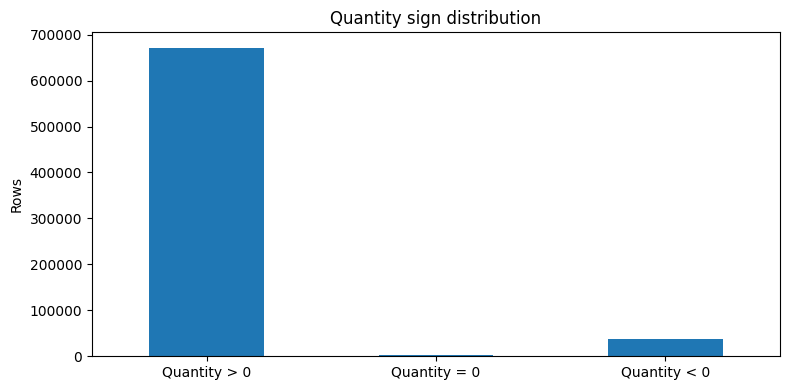

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
qty_summary.plot(kind="bar", x="type", y="rows", ax=ax, legend=False)
ax.set_title("Quantity sign distribution")
ax.set_xlabel("")
ax.set_ylabel("Rows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Profit weight theo WRMSSE

WRMSSE không chấm đều tất cả SKU. Mỗi SKU được weighted theo cumulative profit trong train:

```text
profit_i = sum(SalesAmount - Cost Amount)
profit_i <= 0 -> weight = 0
weight_i = profit_i / sum(profit dương)
```

Vì vậy EDA phải trả lời câu hỏi: **top SKU chiếm bao nhiêu % total profit weight?** Đây là lý do pipeline cuối tập trung model vào top-weight SKU và không tốn capacity cho SKU weight bằng 0.

In [7]:
profit_df = (
    train.groupby("ItemCode", as_index=False)
    .agg(
        total_profit=("line_profit", "sum"),
        total_sales_amount=("SalesAmount", "sum"),
        total_cost_amount=("Cost Amount", "sum"),
        total_positive_qty=("demand_qty", "sum"),
        total_return_qty=("return_qty", "sum"),
        n_rows=("ItemCode", "size"),
        n_active_days=("Date", "nunique"),
        first_date=("Date", "min"),
        last_date=("Date", "max"),
    )
)
profit_df["profit_pos"] = profit_df["total_profit"].clip(lower=0)
total_positive_profit = profit_df["profit_pos"].sum()
profit_df["weight"] = np.where(total_positive_profit > 0, profit_df["profit_pos"] / total_positive_profit, 0)
profit_df = profit_df.sort_values(["weight", "ItemCode"], ascending=[False, True]).reset_index(drop=True)
profit_df["profit_rank"] = np.arange(1, len(profit_df) + 1)
profit_df["cum_weight"] = profit_df["weight"].cumsum()

print("Total SKUs:", len(profit_df))
print("Positive-profit SKUs:", int((profit_df["profit_pos"] > 0).sum()))
print("Zero/negative-profit SKUs:", int((profit_df["profit_pos"] <= 0).sum()))
print("Total positive profit:", f"{total_positive_profit:,.0f}")
display(profit_df.head(20))

Total SKUs: 15972
Positive-profit SKUs: 14156
Zero/negative-profit SKUs: 1816
Total positive profit: 172,197,100,139


,ItemCode,total_profit,total_sales_amount,total_cost_amount,total_positive_qty,total_return_qty,n_rows,n_active_days,first_date,last_date,profit_pos,weight,profit_rank,cum_weight
0,SKU-00003,"16,700,681,088.000000",16700681088,0.000000,10935,0.000000,10936,1061,2022-01-03,2025-09-04,"16,700,681,088.000000",0.096986,1,0.096986
1,SKU-00002,"8,012,686,409.000000",8012686409,0.000000,5894,0.000000,5896,895,2022-01-10,2025-09-05,"8,012,686,409.000000",0.046532,2,0.143518
2,SKU-09458,"2,641,120,895.490000",10081348060,"7,440,227,164.510000",62430,3.000000,154,84,2020-11-17,2024-04-24,"2,641,120,895.490000",0.015338,3,0.158856
3,SKU-00005,"2,243,340,437.000000",2243340437,0.000000,1101,0.000000,1103,327,2022-01-03,2023-06-26,"2,243,340,437.000000",0.013028,4,0.171883
4,SKU-08589,"1,285,705,360.510000",4882727643,"3,597,022,282.490000",29011,0.000000,106,54,2021-05-11,2025-05-15,"1,285,705,360.510000",0.007466,5,0.179350
5,SKU-12534,"1,215,803,793.000000",5356791254,"4,140,987,461.000000",28486,137.000000,1556,661,2021-03-17,2025-09-04,"1,215,803,793.000000",0.007061,6,0.186410
6,SKU-09760,"1,195,313,057.000000",5971433907,"4,776,120,850.000000",222295,"1,874.000000",3843,996,2022-01-03,2025-09-05,"1,195,313,057.000000",0.006942,7,0.193352
7,SKU-12537,"1,106,799,793.000000",4576081190,"3,469,281,397.000000",24127,91.000000,1624,679,2021-03-17,2025-08-12,"1,106,799,793.000000",0.006428,8,0.199780
8,SKU-00324,"978,374,716.170000",5669204524,"4,690,829,807.830000",4800,90.000000,2488,737,2022-01-03,2025-02-13,"978,374,716.170000",0.005682,9,0.205461
9,SKU-14323,"937,104,039.810000",4229909138,"3,292,805,098.190000",18183,265.000000,3536,850,2022-01-03,2025-09-05,"937,104,039.810000",0.005442,10,0.210903


### 5.1 Top SKU chiếm bao nhiêu % profit?

Đây là insight trọng tâm của EDA. Metric WRMSSE không chấm đều 15,972 SKU mà weighted theo profit. Vì vậy cần biết top bao nhiêu SKU đã chiếm 50%, 70%, 80%, 90%, 95% và 99% profit weight.

Kết quả ở bảng dưới là cơ sở để final pipeline chọn nhóm top-weight SKU, đặc biệt mốc **top 2,892 SKU**.


In [8]:
def coverage_for_top_n(df, n):
    n = min(n, len(df))
    return df.loc[:n-1, "weight"].sum()

fixed_top_n = [10, 20, 50, 100, 200, 500, 748, 1000, 1404, 2000, 2892, 4590, 8455]
coverage_table = pd.DataFrame({
    "top_n_sku": fixed_top_n,
    "profit_weight_coverage": [coverage_for_top_n(profit_df, n) for n in fixed_top_n],
})
coverage_table["profit_weight_pct"] = coverage_table["profit_weight_coverage"] * 100
coverage_table["remaining_weight_pct"] = 100 - coverage_table["profit_weight_pct"]
display(coverage_table)

thresholds = [0.50, 0.70, 0.80, 0.90, 0.95, 0.99]
threshold_rows = []
for t in thresholds:
    idx = int(np.searchsorted(profit_df["cum_weight"].values, t, side="left")) + 1
    threshold_rows.append({
        "coverage_target": f"{int(t*100)}%",
        "n_sku_needed": idx,
        "actual_coverage_pct": profit_df.loc[idx-1, "cum_weight"] * 100,
    })
threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

,top_n_sku,profit_weight_coverage,profit_weight_pct,remaining_weight_pct
0,10,0.210903,21.090326,78.909674
1,20,0.251326,25.132593,74.867407
2,50,0.322472,32.247151,67.752849
3,100,0.398178,39.817847,60.182153
4,200,0.490764,49.076363,50.923637
5,500,0.633820,63.382047,36.617953
6,748,0.700039,70.003899,29.996101
7,1000,0.747270,74.727017,25.272983
8,1404,0.800109,80.010870,19.989130
9,2000,0.851769,85.176934,14.823066


,coverage_target,n_sku_needed,actual_coverage_pct
0,50%,214,50.054248
1,70%,748,70.003899
2,80%,1404,80.010870
3,90%,2892,90.000363
4,95%,4590,95.000658
5,99%,8455,99.000129


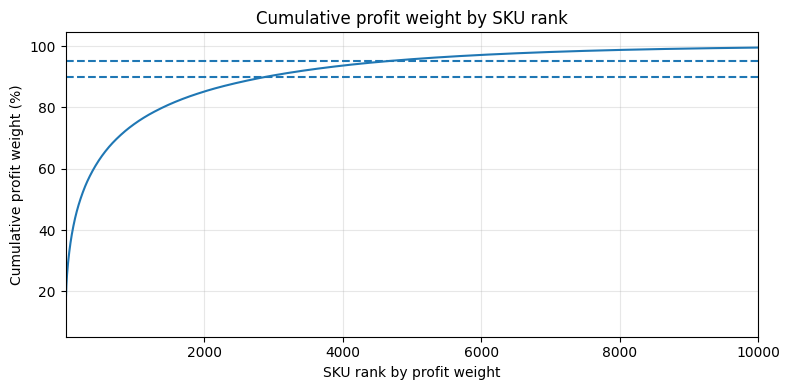

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(profit_df["profit_rank"], profit_df["cum_weight"] * 100)
ax.axhline(90, linestyle="--")
ax.axhline(95, linestyle="--")
ax.set_title("Cumulative profit weight by SKU rank")
ax.set_xlabel("SKU rank by profit weight")
ax.set_ylabel("Cumulative profit weight (%)")
ax.set_xlim(1, min(10000, len(profit_df)))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

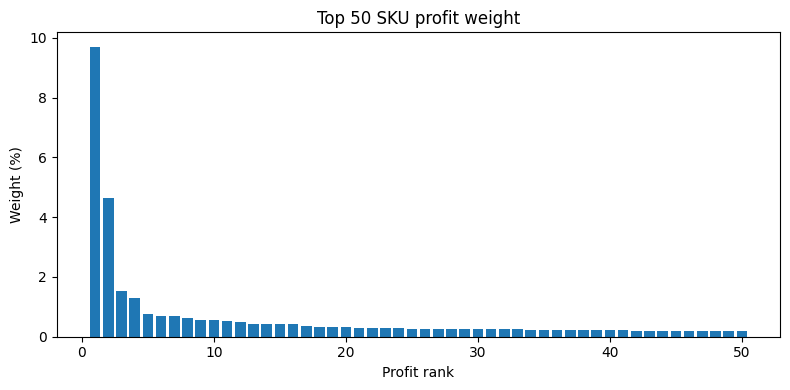

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = profit_df.head(50)
ax.bar(plot_df["profit_rank"], plot_df["weight"] * 100)
ax.set_title("Top 50 SKU profit weight")
ax.set_xlabel("Profit rank")
ax.set_ylabel("Weight (%)")
plt.tight_layout()
plt.show()

### 5.2 Kết luận EDA từ profit weight

Từ bảng coverage, pipeline cuối chọn nhóm top-weight SKU để train model mạnh hơn. Trong bản final, nhóm model chính dùng **top 2,892 SKU**, vì nhóm này bao phủ phần lớn total profit weight, còn các SKU đuôi dài cần dự báo an toàn để tránh overpredict.

## 6. Long-tail demand và SKU sparsity

Bộ dữ liệu là retail demand forecasting dạng long-tail: nhiều SKU bán rất thưa, một số ít SKU đóng góp lớn về profit/demand. Điều này ảnh hưởng trực tiếp đến feature engineering và post-processing.

In [11]:
daily_demand = (
    train.groupby(["ItemCode", "Date"], as_index=False)
    .agg(
        y=("demand_qty", "sum"),
        return_qty=("return_qty", "sum"),
        sales_amount=("SalesAmount", "sum"),
        cost_amount=("Cost Amount", "sum"),
        profit=("line_profit", "sum"),
    )
)

calendar_days = (train["Date"].max() - train["Date"].min()).days + 1
sku_activity = (
    daily_demand.groupby("ItemCode", as_index=False)
    .agg(
        active_days=("Date", "nunique"),
        total_demand=("y", "sum"),
        mean_demand_on_active_day=("y", "mean"),
        max_daily_demand=("y", "max"),
        total_return_qty=("return_qty", "sum"),
    )
    .merge(profit_df[["ItemCode", "weight", "profit_rank", "cum_weight"]], on="ItemCode", how="left")
)
sku_activity["active_day_ratio"] = sku_activity["active_days"] / calendar_days
sku_activity = sku_activity.sort_values(["weight", "ItemCode"], ascending=[False, True]).reset_index(drop=True)

display(sku_activity.head(20))

,ItemCode,active_days,total_demand,mean_demand_on_active_day,max_daily_demand,total_return_qty,weight,profit_rank,cum_weight,active_day_ratio
0,SKU-00003,1061,10935,10.306315,61,0.000000,0.096986,1,0.096986,0.604903
1,SKU-00002,895,5894,6.585475,42,0.000000,0.046532,2,0.143518,0.510262
2,SKU-09458,84,62430,743.214286,5998,3.000000,0.015338,3,0.158856,0.047891
3,SKU-00005,327,1101,3.366972,34,0.000000,0.013028,4,0.171883,0.186431
4,SKU-08589,54,29011,537.240741,3502,0.000000,0.007466,5,0.179350,0.030787
5,SKU-12534,661,28486,43.095310,1026,137.000000,0.007061,6,0.186410,0.376853
6,SKU-09760,996,222295,223.187751,10358,"1,874.000000",0.006942,7,0.193352,0.567845
7,SKU-12537,679,24127,35.533137,935,91.000000,0.006428,8,0.199780,0.387115
8,SKU-00324,737,4800,6.512890,256,90.000000,0.005682,9,0.205461,0.420182
9,SKU-14323,850,18183,21.391765,740,265.000000,0.005442,10,0.210903,0.484607


In [12]:
sparsity_bins = [0, 1, 3, 7, 14, 28, 56, 112, 365, calendar_days + 1]
sparsity_labels = ["1", "2-3", "4-7", "8-14", "15-28", "29-56", "57-112", "113-365", ">365"]
sku_activity["active_days_bucket"] = pd.cut(
    sku_activity["active_days"],
    bins=sparsity_bins,
    labels=sparsity_labels,
    include_lowest=True,
    right=True,
)

sparsity_summary = (
    sku_activity.groupby("active_days_bucket", observed=False)
    .agg(
        n_sku=("ItemCode", "count"),
        total_weight=("weight", "sum"),
        median_total_demand=("total_demand", "median"),
        mean_total_demand=("total_demand", "mean"),
    )
    .reset_index()
)
sparsity_summary["weight_pct"] = sparsity_summary["total_weight"] * 100
display(sparsity_summary)

,active_days_bucket,n_sku,total_weight,median_total_demand,mean_total_demand,weight_pct
0,1,3256,0.005712,1.000000,2.520270,0.571175
1,2-3,2772,0.009268,3.000000,5.566017,0.926837
2,4-7,2473,0.018939,6.000000,10.972503,1.893932
3,8-14,2066,0.030279,13.000000,28.827202,3.027906
4,15-28,1913,0.053033,28.000000,57.927339,5.303263
5,29-56,1392,0.076123,59.000000,132.369253,7.612282
6,57-112,999,0.117620,134.000000,326.960961,11.762049
7,113-365,883,0.275628,401.000000,835.793884,27.562793
8,>365,218,0.413398,"1,938.000000","4,880.967890",41.339764


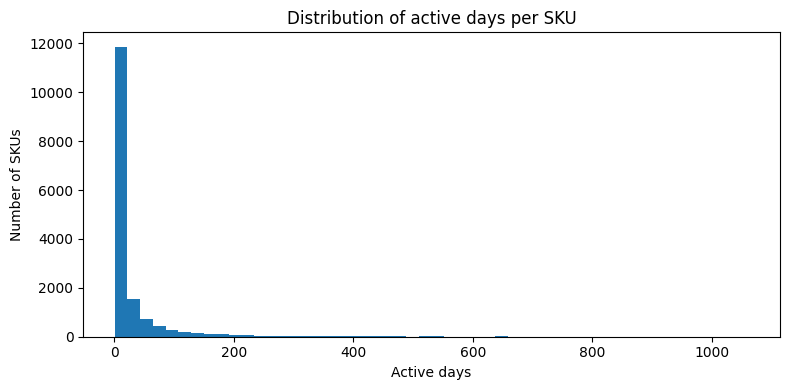

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sku_activity["active_days"], bins=50)
ax.set_title("Distribution of active days per SKU")
ax.set_xlabel("Active days")
ax.set_ylabel("Number of SKUs")
plt.tight_layout()
plt.show()

## 7. Calendar pattern và daily demand trend

Phần này được tính theo đúng logic của notebook final: tạo đủ toàn bộ calendar date từ ngày đầu đến ngày cuối train, sau đó fill các ngày không phát sinh giao dịch bằng 0. Như vậy biểu đồ weekday phản ánh đúng bài toán daily forecasting, trong đó ngày không bán cũng là demand = 0.


In [14]:
# Aggregate total daily demand from transaction-level data
daily_total_raw = (
    daily_demand.groupby("Date", as_index=False)
    .agg(
        total_demand=("y", "sum"),
        total_return_qty=("return_qty", "sum"),
        total_profit=("profit", "sum"),
        active_sku=("ItemCode", "nunique"),
    )
)

# Align with the final forecasting pipeline:
# every calendar day between the first and last training date must exist.
# Dates without transactions are filled as zero demand.
all_dates = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")

daily_total = (
    pd.DataFrame({"Date": all_dates})
    .merge(daily_total_raw, on="Date", how="left")
)

fill_values = {
    "total_demand": 0.0,
    "total_return_qty": 0.0,
    "total_profit": 0.0,
    "active_sku": 0.0,
}
daily_total = daily_total.fillna(fill_values)
daily_total["active_sku"] = daily_total["active_sku"].astype(int)

daily_total["day_of_week"] = daily_total["Date"].dt.day_name()
daily_total["month"] = daily_total["Date"].dt.to_period("M").astype(str)

print("Raw transaction days:", daily_total_raw["Date"].nunique())
print("Full calendar days:", daily_total["Date"].nunique())
print("Zero-transaction calendar days added:", int((daily_total["total_demand"] == 0).sum()))

display(daily_total.tail())


Raw transaction days: 1411
Full calendar days: 1754
Zero-transaction calendar days added: 344


,Date,total_demand,total_return_qty,total_profit,active_sku,day_of_week,month
1749,2025-09-01,0.000000,0.000000,0.000000,0,Monday,2025-09
1750,2025-09-02,0.000000,0.000000,0.000000,0,Tuesday,2025-09
1751,2025-09-03,"1,450.000000",45.000000,"110,179,683.870000",414,Wednesday,2025-09
1752,2025-09-04,"2,818.000000",34.000000,"115,881,863.370000",387,Thursday,2025-09
1753,2025-09-05,"1,391.000000",68.000000,"81,462,571.570000",421,Friday,2025-09


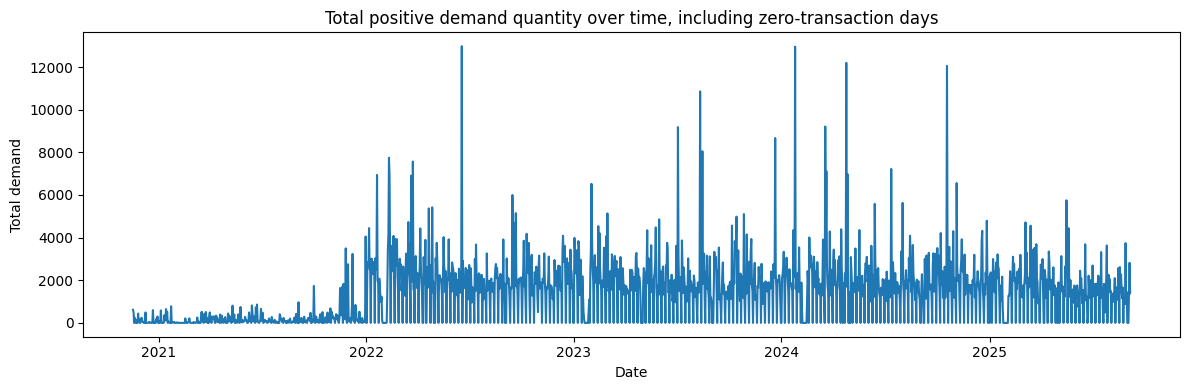

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(daily_total["Date"], daily_total["total_demand"])
ax.set_title("Total positive demand quantity over time, including zero-transaction days")
ax.set_xlabel("Date")
ax.set_ylabel("Total demand")
plt.tight_layout()
plt.show()


,day_of_week,mean_total_demand,median_total_demand,mean_active_sku,n_calendar_days
0,Monday,"1,816.712000","1,866.500000",371.360000,250
1,Tuesday,"1,688.171315","1,727.000000",351.513944,251
2,Wednesday,"1,769.378486","1,686.000000",338.119522,251
3,Thursday,"1,777.840637","1,698.000000",330.697211,251
4,Friday,"1,764.944223","1,660.000000",331.171315,251
5,Saturday,"1,289.036000","1,395.500000",299.860000,250
6,Sunday,2.280000,0.000000,0.072000,250


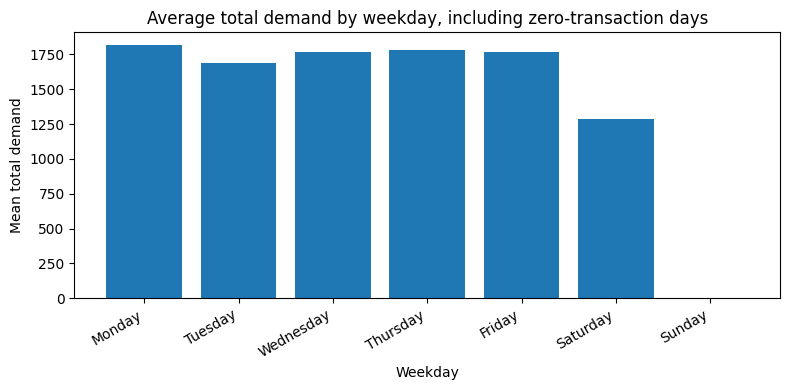

In [16]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = (
    daily_total.groupby("day_of_week")
    .agg(
        mean_total_demand=("total_demand", "mean"),
        median_total_demand=("total_demand", "median"),
        mean_active_sku=("active_sku", "mean"),
        n_calendar_days=("Date", "size"),
    )
    .reindex(dow_order)
    .reset_index()
)
display(dow_summary)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_summary["day_of_week"], dow_summary["mean_total_demand"])
ax.set_title("Average total demand by weekday, including zero-transaction days")
ax.set_xlabel("Weekday")
ax.set_ylabel("Mean total demand")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 8. Top-weight SKU behavior

Phần này xem riêng nhóm SKU có weight cao, vì nhóm này ảnh hưởng mạnh nhất đến WRMSSE. Sai lệch nhỏ ở một SKU weight lớn có thể ảnh hưởng score nhiều hơn hàng nghìn SKU đuôi dài.

In [17]:
TOP_N_FOR_EDA = 50
top_skus = profit_df.head(TOP_N_FOR_EDA)["ItemCode"].tolist()

top_daily = daily_demand[daily_demand["ItemCode"].isin(top_skus)].copy()

top_sku_summary = (
    top_daily.groupby("ItemCode", as_index=False)
    .agg(
        total_demand=("y", "sum"),
        active_days=("Date", "nunique"),
        mean_demand=("y", "mean"),
        max_daily_demand=("y", "max"),
        total_return_qty=("return_qty", "sum"),
    )
    .merge(profit_df[["ItemCode", "weight", "profit_rank", "cum_weight"]], on="ItemCode", how="left")
    .sort_values("weight", ascending=False)
)

display(top_sku_summary.head(50))

,ItemCode,total_demand,active_days,mean_demand,max_daily_demand,total_return_qty,weight,profit_rank,cum_weight
1,SKU-00003,10935,1061,10.306315,61,0.000000,0.096986,1,0.096986
0,SKU-00002,5894,895,6.585475,42,0.000000,0.046532,2,0.143518
25,SKU-09458,62430,84,743.214286,5998,3.000000,0.015338,3,0.158856
3,SKU-00005,1101,327,3.366972,34,0.000000,0.013028,4,0.171883
23,SKU-08589,29011,54,537.240741,3502,0.000000,0.007466,5,0.179350
39,SKU-12534,28486,661,43.095310,1026,137.000000,0.007061,6,0.186410
30,SKU-09760,222295,996,223.187751,10358,"1,874.000000",0.006942,7,0.193352
40,SKU-12537,24127,679,35.533137,935,91.000000,0.006428,8,0.199780
5,SKU-00324,4800,737,6.512890,256,90.000000,0.005682,9,0.205461
43,SKU-14323,18183,850,21.391765,740,265.000000,0.005442,10,0.210903


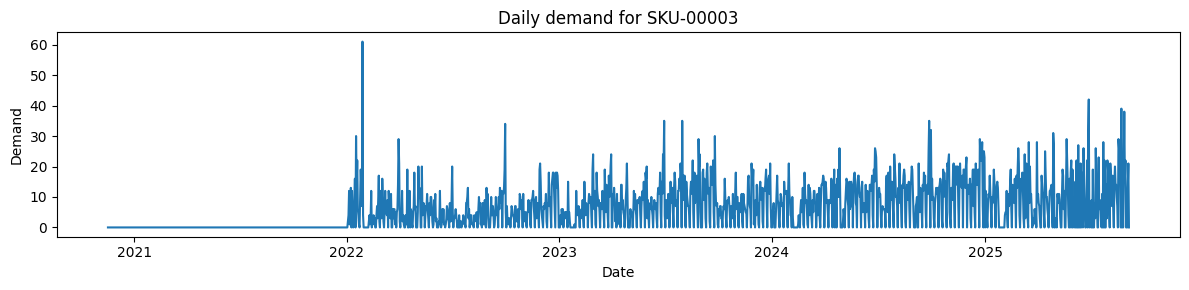

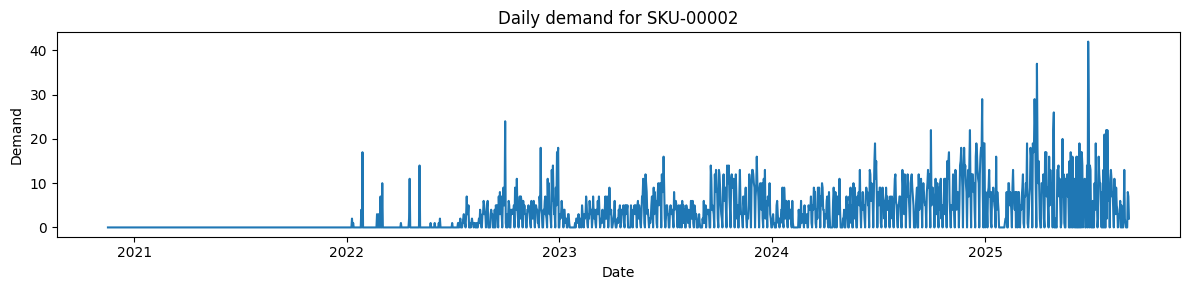

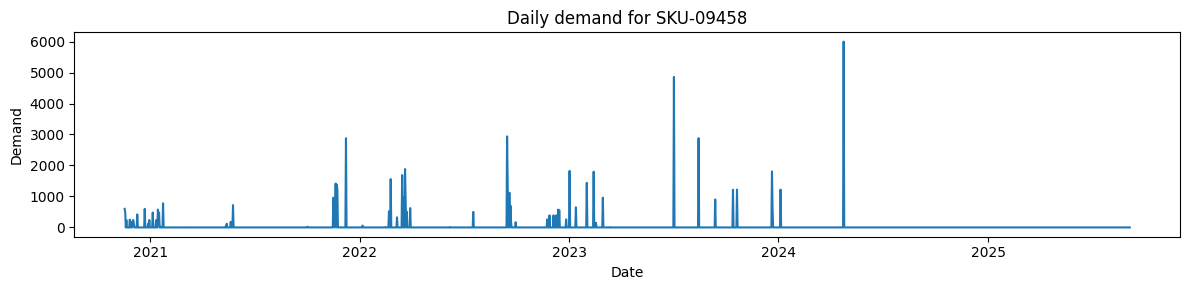

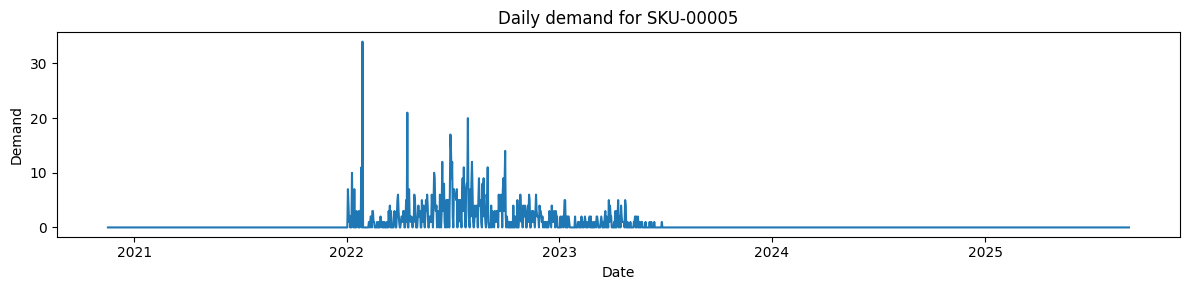

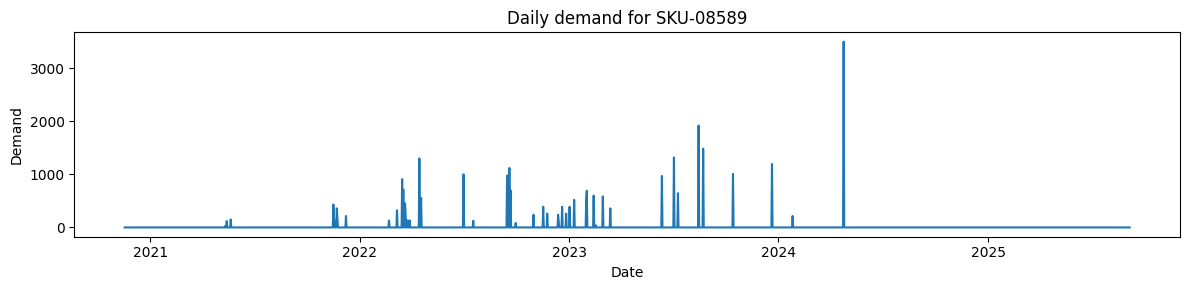

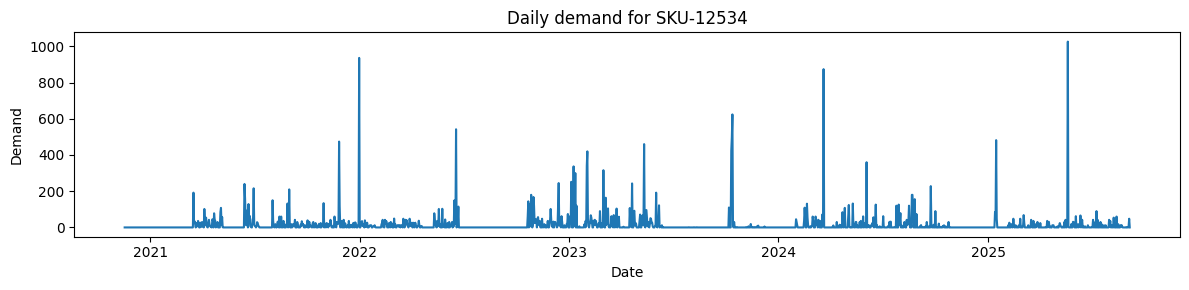

In [18]:
plot_skus = profit_df.head(6)["ItemCode"].tolist()
for sku in plot_skus:
    tmp = top_daily[top_daily["ItemCode"] == sku].set_index("Date").sort_index()
    full_idx = pd.date_range(train["Date"].min(), train["Date"].max(), freq="D")
    y = tmp["y"].reindex(full_idx, fill_value=0)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(y.index, y.values)
    ax.set_title(f"Daily demand for {sku}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Demand")
    plt.tight_layout()
    plt.show()

## 9. Recent demand vs historical behavior

Final model dùng lag/rolling features và sau đó thêm SKU-level correction factor. EDA dưới đây xem tương quan giữa recent demand và historical average của top SKU để thấy vì sao forecast cần điều chỉnh theo từng SKU.

In [19]:
last_date = train["Date"].max()
recent_start = last_date - pd.Timedelta(days=27)
prev_start = recent_start - pd.Timedelta(days=28)
prev_end = recent_start - pd.Timedelta(days=1)

recent_28 = (
    daily_demand[(daily_demand["Date"] >= recent_start) & (daily_demand["Date"] <= last_date)]
    .groupby("ItemCode")["y"].sum()
    .rename("recent_28_demand")
    .reset_index()
)
prev_28 = (
    daily_demand[(daily_demand["Date"] >= prev_start) & (daily_demand["Date"] <= prev_end)]
    .groupby("ItemCode")["y"].sum()
    .rename("prev_28_demand")
    .reset_index()
)

recent_analysis = (
    profit_df[["ItemCode", "weight", "profit_rank", "cum_weight"]]
    .merge(recent_28, on="ItemCode", how="left")
    .merge(prev_28, on="ItemCode", how="left")
    .fillna({"recent_28_demand": 0, "prev_28_demand": 0})
)
recent_analysis["recent_vs_prev_ratio"] = (recent_analysis["recent_28_demand"] + 1) / (recent_analysis["prev_28_demand"] + 1)

display(recent_analysis.head(50))

,ItemCode,weight,profit_rank,cum_weight,recent_28_demand,prev_28_demand,recent_vs_prev_ratio
0,SKU-00003,0.096986,1,0.096986,356.000000,272.000000,1.307692
1,SKU-00002,0.046532,2,0.143518,98.000000,226.000000,0.436123
2,SKU-09458,0.015338,3,0.158856,0.000000,0.000000,1.000000
3,SKU-00005,0.013028,4,0.171883,0.000000,0.000000,1.000000
4,SKU-08589,0.007466,5,0.179350,0.000000,0.000000,1.000000
5,SKU-12534,0.007061,6,0.186410,166.000000,246.000000,0.676113
6,SKU-09760,0.006942,7,0.193352,"2,338.000000","2,170.000000",1.077384
7,SKU-12537,0.006428,8,0.199780,44.000000,322.000000,0.139319
8,SKU-00324,0.005682,9,0.205461,0.000000,0.000000,1.000000
9,SKU-14323,0.005442,10,0.210903,628.000000,717.000000,0.876045


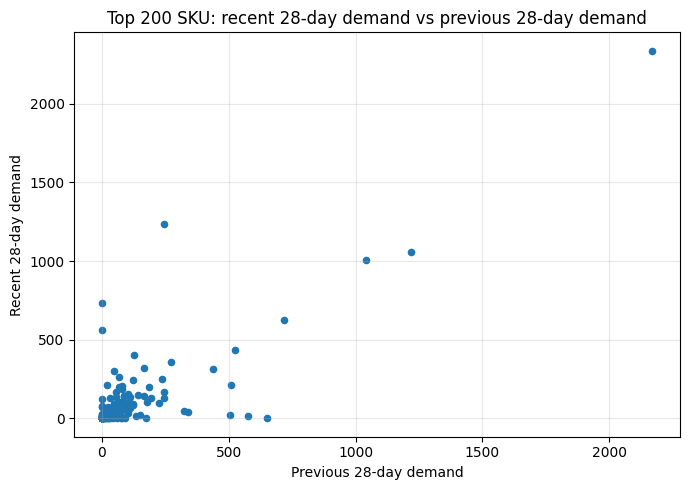

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_df = recent_analysis.head(200)
ax.scatter(plot_df["prev_28_demand"], plot_df["recent_28_demand"], s=20)
ax.set_title("Top 200 SKU: recent 28-day demand vs previous 28-day demand")
ax.set_xlabel("Previous 28-day demand")
ax.set_ylabel("Recent 28-day demand")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. RMSSE denominator intuition

RMSSE chia lỗi dự báo cho scale lịch sử của từng SKU. SKU có demand ổn định/thấp scale có thể bị phạt mạnh nếu overpredict. Vì vậy pipeline final không chỉ dự báo trung bình mà còn dùng correction factor cho một số SKU top contribution.

In [21]:
def compute_rmsse_scale_per_sku(daily_df, all_skus=None):
    if all_skus is None:
        all_skus = daily_df["ItemCode"].unique()
    min_date = train["Date"].min()
    max_date = train["Date"].max()
    full_dates = pd.date_range(min_date, max_date, freq="D")

    rows = []
    for sku in all_skus:
        tmp = daily_df[daily_df["ItemCode"] == sku].set_index("Date").sort_index()
        y = tmp["y"].reindex(full_dates, fill_value=0).values.astype(float)
        if len(y) > 1:
            scale = np.mean(np.diff(y) ** 2)
        else:
            scale = np.nan
        rows.append((sku, scale))
    return pd.DataFrame(rows, columns=["ItemCode", "rmsse_scale"])

scale_df = compute_rmsse_scale_per_sku(daily_demand, profit_df.head(200)["ItemCode"].tolist())
scale_df = scale_df.merge(profit_df[["ItemCode", "weight", "profit_rank"]], on="ItemCode", how="left")
scale_df = scale_df.sort_values("weight", ascending=False)
display(scale_df.head(50))

,ItemCode,rmsse_scale,weight,profit_rank
0,SKU-00003,61.625784,0.096986,1
1,SKU-00002,24.374216,0.046532,2
2,SKU-09458,"137,529.812892",0.015338,3
3,SKU-00005,4.423274,0.013028,4
4,SKU-08589,"38,186.784940",0.007466,5
5,SKU-12534,"6,121.712493",0.007061,6
6,SKU-09760,"379,528.625214",0.006942,7
7,SKU-12537,"3,603.788933",0.006428,8
8,SKU-00324,264.902453,0.005682,9
9,SKU-14323,"1,809.498003",0.005442,10


## 11. EDA Findings and Modeling Decisions

Bảng dưới đây tóm tắt mối liên hệ giữa phát hiện từ EDA và quyết định được dùng trong pipeline final. Đây là phần quan trọng để người đọc thấy rằng source code/model không được chọn ngẫu nhiên mà xuất phát từ đặc điểm dữ liệu và metric WRMSSE.

| EDA finding | Modeling decision trong pipeline final |
|---|---|
| Dữ liệu có các dòng `Quantity < 0`, liên quan đến return/adjustment/hàng rời kho nhưng không phải demand bán thường. | Tạo target không âm: `demand_qty = max(Quantity, 0)`. Final submission cũng clip prediction không âm. |
| WRMSSE weighted theo cumulative profit; SKU có `profit <= 0` có weight bằng 0. | Tính `profit weight` theo SKU trước khi train, ưu tiên SKU có weight cao và tránh để SKU weight thấp làm nhiễu objective. |
| Profit weight phân bố rất lệch: một nhóm nhỏ SKU chiếm phần lớn total profit. | Train model chính cho nhóm top-weight SKU; pipeline final dùng top 2,892 SKU vì nhóm này bao phủ phần lớn profit weight. |
| Demand có long-tail và nhiều SKU bán thưa/sparse. | Với SKU đuôi dài, dùng dự báo an toàn/baseline thay vì cố train model phức tạp cho toàn bộ SKU như nhau. |
| Nhu cầu thay đổi theo thời gian và có pattern theo ngày/tuần. | Tạo lag features, rolling mean/std và calendar features để LightGBM học dynamic demand. |
| Một số SKU top-weight bị lệch scale dự báo trong rolling validation, đặc biệt overpredict/underpredict tổng 28 ngày. | Áp dụng SKU-level correction factor có shrink cho một số SKU top-contribution để giảm lỗi WRMSSE nhưng hạn chế overfit. |

Tóm lại, pipeline cuối đi theo logic:

```text
EDA → positive-demand target → profit-weighted SKU selection → lag/rolling features → LightGBM ratio model → SKU-level correction factor → final submission
```

Các bước tạo feature, train model và xuất submission nằm ở:

```text
02_data_preprocessing.ipynb
03_model_training_submission.ipynb
src/pipeline.py
src/run_final_submission.py
```


In [22]:
coverage_table.to_csv(OUTPUT_DIR / "profit_weight_coverage.csv", index=False)
threshold_table.to_csv(OUTPUT_DIR / "profit_weight_thresholds.csv", index=False)
sparsity_summary.to_csv(OUTPUT_DIR / "sku_sparsity_summary.csv", index=False)
top_sku_summary.to_csv(OUTPUT_DIR / "top50_sku_summary.csv", index=False)
recent_analysis.head(200).to_csv(OUTPUT_DIR / "top200_recent_demand_analysis.csv", index=False)

print("Saved EDA tables to:", OUTPUT_DIR)

Saved EDA tables to: /Users/apple/HBAAC/hbaac_demand_forecasting_repo/outputs/eda
